# 11 - 1D Signal Generation (Solution)

This notebook generates synthetic sensor signals for four machine conditions and compares waveform and FFT views.

MATLAB to Python note:
- MATLAB: `fft(x)`
- Python: `np.fft.rfft(x)`

### Step 1 README: Environment Setup
This cell configures path discovery so imports work regardless of where you launch the notebook, then imports all Day 5 utilities.

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "edge_ai_course").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise ModuleNotFoundError(
        "Could not find src/edge_ai_course. Run from inside the 'day 5 sensor' folder or a child folder."
    )

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from edge_ai_course.signal_generator import SignalConfig, CLASS_ID_TO_NAME, generate_source_signals
from edge_ai_course.signal_dataset import build_sensor_dataset, save_dataset_artifacts, assert_no_source_leakage
from edge_ai_course.signal_features import extract_features, fft_components
from edge_ai_course.signal_models import train_classical_models, train_cnn_model, convert_to_tflite
from edge_ai_course.signal_visualization import plot_signal_and_fft, plot_feature_distribution, plot_confusion_matrix, plot_comparison_bars
from edge_ai_course.model_analysis import (
    build_comparison_table,
    write_day5_report,
    estimate_classical_pipeline_memory,
    estimate_cnn_pipeline_memory,
)

print("Environment ready for Notebook 11")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python executable: {sys.executable}")
print(f"NumPy version: {np.__version__}")

Environment ready for Notebook 11
Project root: C:\Users\thenebandaa\OneDrive - West Pharmaceutical Services, Inc\trainings\Edge AI\code\day 5 sensor
Python executable: c:\Users\thenebandaa\OneDrive - West Pharmaceutical Services, Inc\trainings\Edge AI\code\.venv\Scripts\python.exe
NumPy version: 1.26.4


### Step 2 README: Generate Source Signals
This cell creates synthetic source signals for the four classes in quick mode and shows class distribution as a bar chart.

Generated 200 source signals


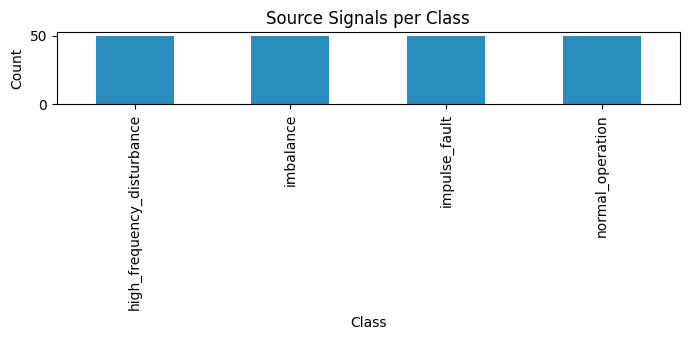

high_frequency_disturbance    50
imbalance                     50
impulse_fault                 50
normal_operation              50
Name: count, dtype: int64

In [3]:
config = SignalConfig(sampling_rate=1000, duration_seconds=4.0, random_seed=42)
examples = generate_source_signals(config=config, mode="quick")
print(f"Generated {len(examples)} source signals")
class_counts = pd.Series([e.class_name for e in examples]).value_counts().sort_index()

plt.figure(figsize=(7, 3.5))
class_counts.plot(kind="bar", color="#2b8cbe")
plt.title("Source Signals per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

class_counts

### Step 3 README: Time + Frequency Visualization
This cell plots full waveform, zoomed waveform, and FFT spectrum for one representative signal per class and saves figures to reports.

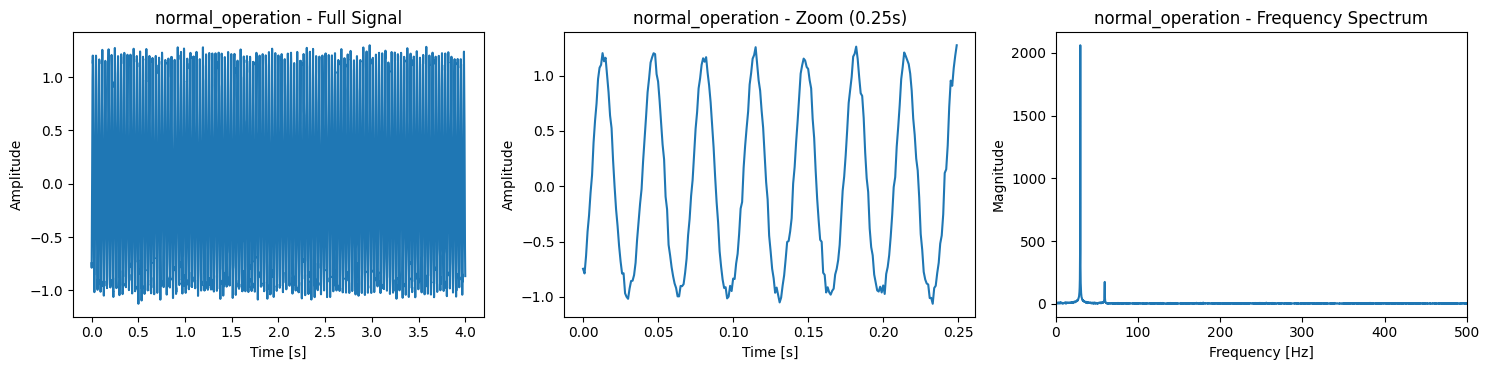

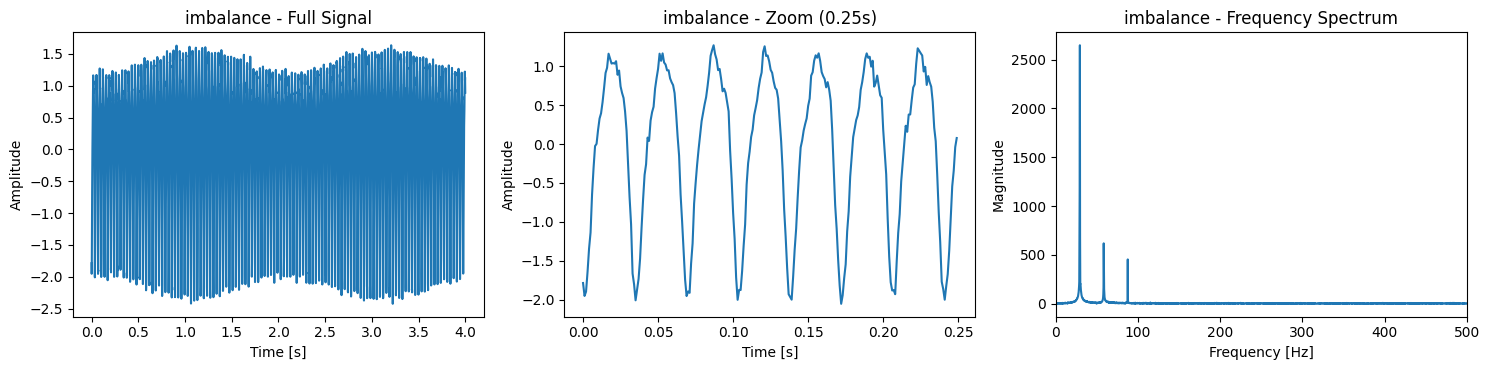

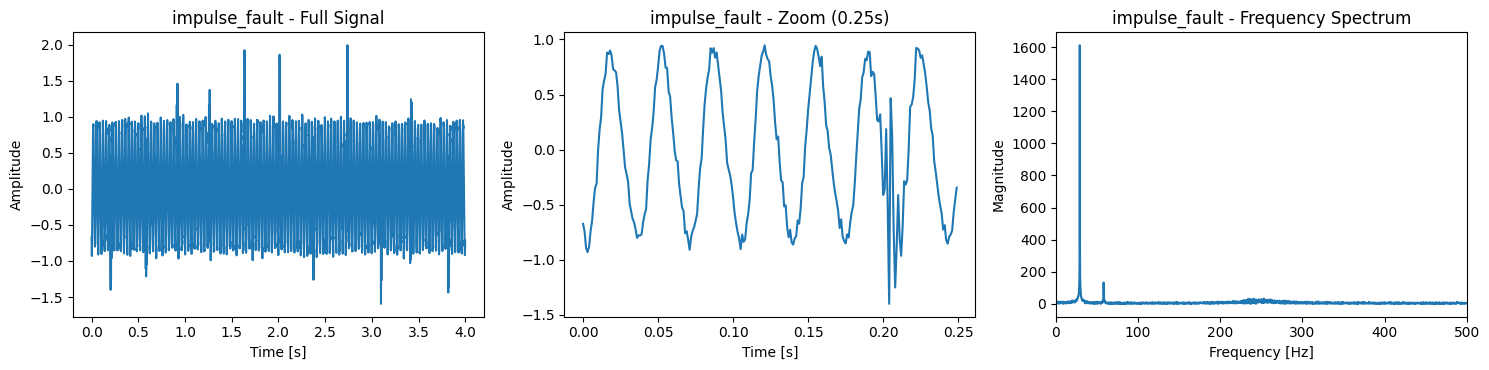

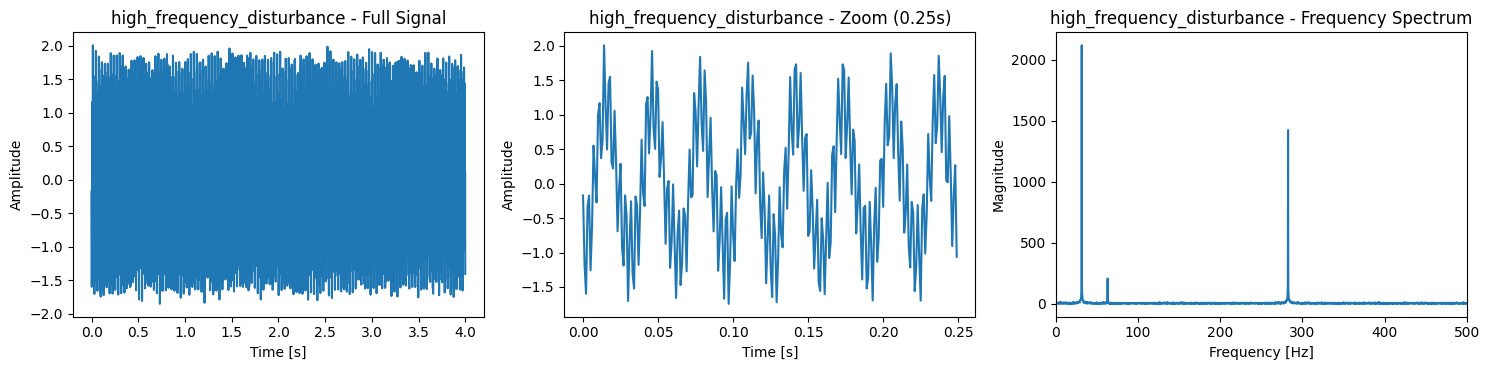

Saved class plots to: C:\Users\thenebandaa\OneDrive - West Pharmaceutical Services, Inc\trainings\Edge AI\code\day 5 sensor\reports\day5\plots


In [5]:
plot_dir = PROJECT_ROOT / "reports" / "day5" / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

# One representative signal per class with full/zoom/FFT views.
for class_id, class_name in CLASS_ID_TO_NAME.items():
    signal = next(e.signal for e in examples if e.class_id == class_id)
    plot_signal_and_fft(
        signal=signal,
        sampling_rate=config.sampling_rate,
        title_prefix=class_name,
        save_path=plot_dir / f"11_signal_fft_{class_name}.png",
    )

print(f"Saved class plots to: {plot_dir}")

### Step 4 README: Noise Sensitivity Experiment
This cell varies noise level and visualizes how waveform quality changes, building intuition for robustness testing.

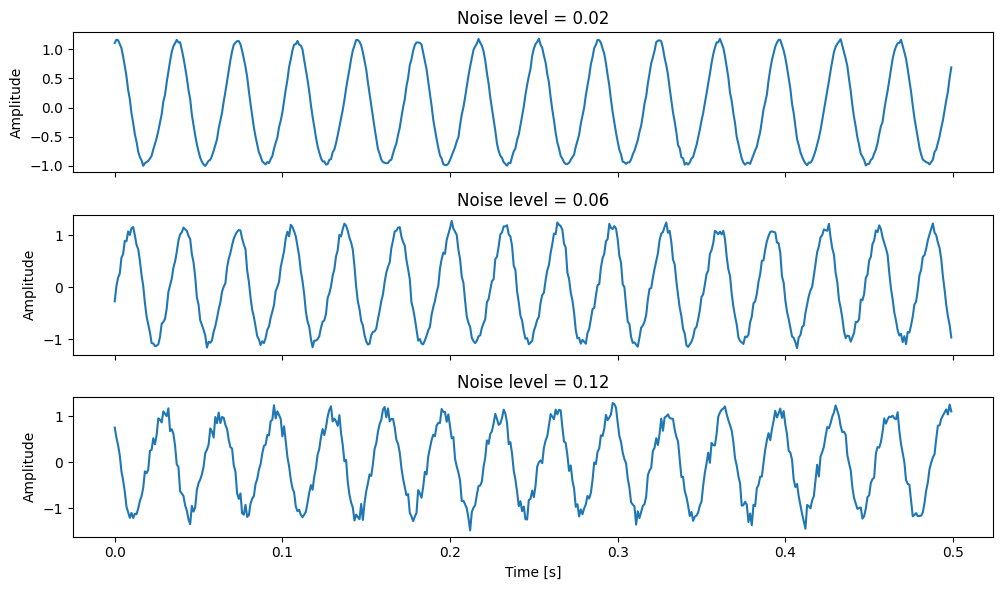

In [6]:
# Configurable experiment: noise and fault severity proxy via sampling different seeds.
noise_levels = [0.02, 0.06, 0.12]
fig, axes = plt.subplots(len(noise_levels), 1, figsize=(10, 6), sharex=True)
for row, noise in enumerate(noise_levels):
    cfg = SignalConfig(sampling_rate=1000, duration_seconds=4.0, noise_level=noise, random_seed=123 + row)
    sig = generate_source_signals(cfg, mode="quick", samples_per_class=1)[0].signal
    t = np.arange(sig.size) / cfg.sampling_rate
    axes[row].plot(t[:500], sig[:500])
    axes[row].set_title(f"Noise level = {noise}")
    axes[row].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()